In [37]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline , Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge, Lasso , RidgeCV 

df = pd.read_csv("california_housing.csv")

• Load the dataset into a DataFrame. Print its shape and the first few rows.

• Inspect feature types and missing values. Decide how you will handle anything missing.

• Write one clear sentence defining the target: what are we predicting, and what do higher values
mean?

• Plot the distribution of the target with a histogram (think about the number of bins). Is it roughly
sensible?

In [38]:
df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,3.7056,22.0,4.4502,1.1416,1773.0,3.0922,40.02,-122.25,1.7255
1,4.8575,36.0,5.7551,1.0897,199.0,3.6810,37.17,-118.79,2.9542
2,3.3045,9.0,8.6213,1.1102,754.0,3.5749,33.68,-115.29,2.1390
3,2.9988,16.0,6.0610,1.1367,310.0,4.7781,36.92,-122.10,1.9076
4,5.2304,6.0,5.2884,1.1086,1322.0,2.5858,41.01,-123.05,2.9634


In [39]:
print(df.shape)

(5000, 9)


In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       5000 non-null   float64
 1   HouseAge     5000 non-null   float64
 2   AveRooms     5000 non-null   float64
 3   AveBedrms    5000 non-null   float64
 4   Population   5000 non-null   float64
 5   AveOccup     5000 non-null   float64
 6   Latitude     5000 non-null   float64
 7   Longitude    5000 non-null   float64
 8   MedHouseVal  5000 non-null   float64
dtypes: float64(9)
memory usage: 351.7 KB


In [41]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,3.510015,26.22600,5.428428,1.105787,1401.835400,2.998402,37.301188,-119.327646,2.209814
std,2.188871,14.63864,1.203382,0.147371,993.938491,0.791911,2.768071,2.856619,1.003127
min,0.500000,1.00000,2.000000,0.800000,100.000000,1.000000,32.510000,-124.300000,0.150000
25%,1.912950,13.00000,4.615000,1.001175,665.000000,2.461050,34.900000,-121.780000,1.498400
50%,3.068800,26.00000,5.397550,1.105200,1180.500000,2.991650,37.350000,-119.330000,2.093450
75%,4.618125,39.00000,6.240350,1.206300,1891.000000,3.527475,39.730000,-116.880000,2.811950
max,15.000000,51.00000,9.240300,1.633500,6000.000000,6.270300,42.000000,-114.300000,5.000000


==>The dataset contains no missing values, so no imputation or other missing-value handling is required.

==>Target: MedHouseVal represents the median house value. Higher values indicate higher median house values.


In [42]:
print(df.columns.tolist())

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


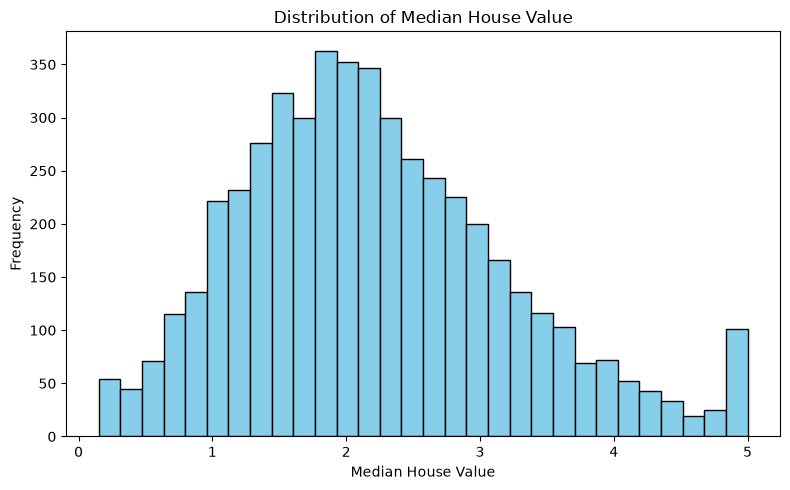

In [43]:
plt.figure(figsize=(8, 5))

plt.hist(df["MedHouseVal"], bins=30, color='skyblue', edgecolor='black')

plt.title("Distribution of Median House Value")
plt.xlabel("Median House Value")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

The target distribution is not perfectly normal and is somewhat skewed. Most observations are concentrated in the lower-to-middle range of house values, with fewer observations at higher values. Overall, the distribution is sensible for a housing-price prediction problem.

**TASK 02 — Make the train/test split once, and freeze the test set**

• Split the data into features X and target y.

• Use train_test_split to carve off a held-out test set (e.g. test_size=0.2). Fix random_state so it is
reproducible

In [44]:
X_train, X_test,y_train, y_test = train_test_split(df.drop("MedHouseVal", axis=1), df["MedHouseVal"], test_size=0.2, random_state=42)


• You will handle the validation step with cross-validation in Part 2.

• Write down, in your notebook, exactly what each part is for: train for learning, validation/CV for
choosing, test for one final check.



- **Training data:** Used to learn the model's parameters from the data.
- **Validation / Cross-Validation (CV):** Used to compare models and choose the best model or hyperparameters without using the test set.
- **Test data:** Kept completely unseen during model selection and tuning. It is used only once at the end for the final evaluation.

**TASK 03 — Build a dumb baseline first**

• For regression, use DummyRegressor with strategy='mean'. For classification, DummyClassifier with
strategy='most_frequent' or 'stratified'.

• Fit it on X_train only, and measure its performance using cross-validation on the training part.

• Record this number in your notebook out loud. It is your floor — every real model must beat it, or
something is wrong.

In [45]:
baseline = DummyRegressor(strategy='mean')
scores = cross_val_score(baseline, X_train, y_train, cv=5)
print('baseline CV R2:', scores.mean().round(3))


baseline CV R2: -0.002


The DummyRegressor using the mean strategy achieved a cross-validation R²
score of -0.002.

This is our baseline performance or "floor".

**TASK 04 — One plain model, and feel the problem**

• Regression: LinearRegression. Classification: LogisticRegression.

• Fit on X_train, score with cross-validation on the training part. Compare to your baseline.

• Now look at the raw coefficient magnitudes. Are some absurdly large? That is the tell — features on
very different scales.

In [46]:
lr = LinearRegression()
lr.fit(X_train, y_train)
print('plain LR CV R2:', cross_val_score(lr, X_train, y_train, cv=5).mean().round(3))
print('coef range:', lr.coef_.min().round(2), 'to', lr.coef_.max().round(2))

plain LR CV R2: 0.84
coef range: -0.14 to 0.4


==>The plain Linear Regression model achieved a CV R² of 0.840, which is substantially higher than the baseline score of -0.002. 

=>This indicates that the dataset's features contain useful information for predicting median house value.

==> > The coefficients ranged from **-0.14 to 0.40**. Since the features have different scales, the coefficients cannot be directly compared.


**TASK 05 — Add Ridge and Lasso, your next variants**

• Standardise features first with StandardScaler — regularised linear models demand it.

• Fit Ridge and fit Lasso on the scaled training data. Compare their CV scores to the plain model and to
the baseline.

• Compare the two coefficient vectors. Which model produces many exact zeros? Why?

In [47]:
scaled_ridge = make_pipeline(StandardScaler(), Ridge())
scaled_lasso = make_pipeline(StandardScaler(), Lasso())

ridge_scores = cross_val_score(
    scaled_ridge,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

lasso_scores = cross_val_score(
    scaled_lasso,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print("Ridge CV R²:", ridge_scores.mean().round(3))
print("Lasso CV R²:", lasso_scores.mean().round(3))

Ridge CV R²: 0.84
Lasso CV R²: -0.002


In [48]:
#Fit the models to the training data

scaled_ridge.fit(X_train, y_train)
scaled_lasso.fit(X_train, y_train)

print("Ridge coefficients:")
print(scaled_ridge.named_steps["ridge"].coef_)

print("\nLasso coefficients:")
print(scaled_lasso.named_steps["lasso"].coef_)

Ridge coefficients:
[ 0.87969133  0.16957032  0.03397028  0.00189702 -0.00217843 -0.11212972
 -0.14909487 -0.16996597]

Lasso coefficients:
[0. 0. 0. 0. 0. 0. 0. 0.]


In [49]:
lasso_coefs = scaled_lasso.named_steps["lasso"].coef_

zero_count = (lasso_coefs == 0).sum()

print("Lasso exact zero coefficients:", zero_count)

Lasso exact zero coefficients: 8


**TASK 06 — Tune your best regularised variant with cross-validation**

• Regression: use LassoCV or RidgeCV, which tune alpha for you. Classification: GridSearchCV or
LogisticRegressionCV over a small alpha grid.

• Fit on the training part only. Record the chosen alpha.

• For a search, try a small grid of alpha values and let CV choose. Read the best score and the best
alpha.

• If you used Lasso, count how many coefficients became zero at the best alpha. This is your
feature-selection story.

In [50]:
ridge_cv = make_pipeline(
    StandardScaler(),
    RidgeCV(alphas=[0.0001, 0.001, 0.01, 0.1, 1, 10], cv=5)
)

ridge_cv.fit(X_train, y_train)

print("Best alpha:", ridge_cv.named_steps["ridgecv"].alpha_)
print("Best CV R²:", cross_val_score(
    ridge_cv,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
).mean().round(3))

Best alpha: 1.0
Best CV R²: 0.84


RidgeCV selected an alpha of 1.0 as the best value. The tuned Ridge model
achieved a CV R² of 0.840, which is the same as the original Ridge model.
Therefore, tuning did not produce a noticeable improvement in CV performance.

**TASK 07 — Wrap it in one clean sklearn Pipeline**

• Combine your chosen preprocessing and your tuned model into one Pipeline.

• Run cross-validation on the pipeline and confirm it matches your earlier CV score.

• This Pipeline is now the single object that represents your best model.

In [51]:

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RidgeCV(alphas=[0.0001, 0.001, 0.01, 0.1, 1, 10], cv=5))
])
pipeline.fit(X_train, y_train)

pipeline_scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print("Pipeline CV R²:", pipeline_scores.mean().round(3))

Pipeline CV R²: 0.84


==> The final Pipeline combines StandardScaler and RidgeCV into a single model.
The Pipeline achieved a CV R² of 0.840, matching the earlier RidgeCV result.
Keeping preprocessing inside the Pipeline helps prevent data leakage during
cross-validation.

**TASK 08 — Interpret the model, do not just report a number**

• Extract the final coefficients from your pipeline's trained model.

• Plot them as a clearly labelled bar chart, one bar per feature.

• For Lasso, this chart is your story — it directly shows which features matter and which are zeroed out.

• Write, in plain language, 3–4 bullet points: which features push the target up or down, and how
confident you feel

In [52]:
coefs = pipeline.named_steps["model"].coef_

coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": coefs
})

print(coef_df)

      Feature  Coefficient
0      MedInc     0.879691
1    HouseAge     0.169570
2    AveRooms     0.033970
3   AveBedrms     0.001897
4  Population    -0.002178
5    AveOccup    -0.112130
6    Latitude    -0.149095
7   Longitude    -0.169966


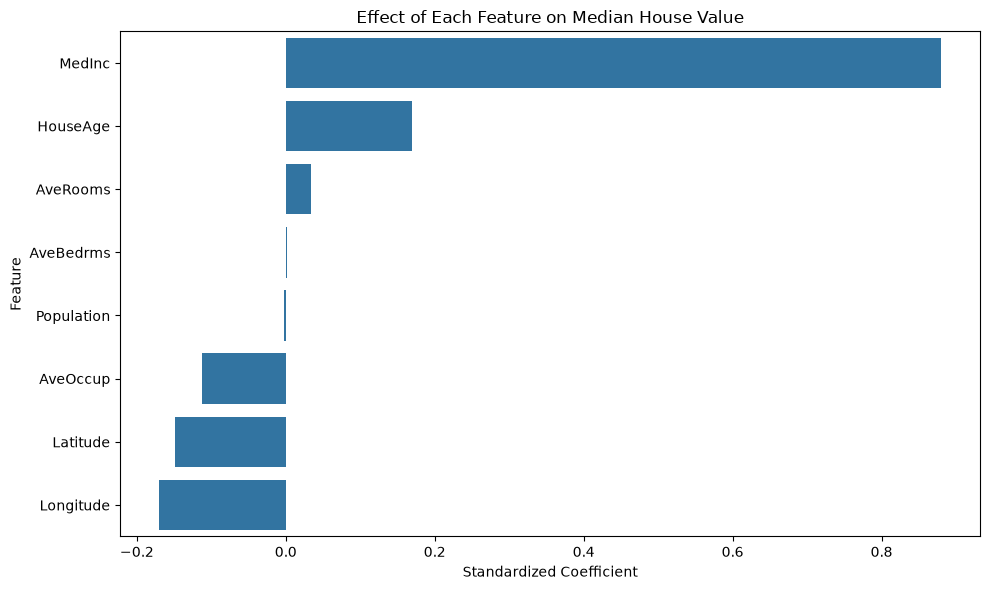

In [60]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=coef_df,
    x="Coefficient",
    y="Feature"
)

plt.title("Effect of Each Feature on Median House Value")
plt.xlabel("Standardized Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.savefig("coefficients.png", dpi=150, bbox_inches="tight")
plt.show()

**TASK 09 — The final score, the comparison table, and the deliverable**

• Evaluate your chosen Pipeline on the held-out test set. Do it once. Record the number.

• Build a comparison table bringing everything together: baseline, plain, Ridge, and Lasso, with their CV
scores and the final test score.

• Structure your repo: notebook + README.md + the chart saved with savefig + the comparison table +
your interpretation.

• Write a short README explaining what you built, how to run it, and what the table means.

In [57]:
final_test_score = pipeline.score(X_test, y_test)

print("FINAL Test R²:", round(final_test_score, 3))


FINAL Test R²: 0.838


In [58]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Plain Linear Regression",
        "Ridge",
        "Lasso",
        "Final RidgeCV Pipeline"
    ],
    "CV R²": [
        scores.mean(),
        cross_val_score(lr, X_train, y_train, cv=5, scoring="r2").mean(),
        ridge_scores.mean(),
        lasso_scores.mean(),
        pipeline_scores.mean()
    ]
})

comparison["CV R²"] = comparison["CV R²"].round(3)

comparison

,Model,CV R²
0,Baseline,-0.002
1,Plain Linear Regression,0.840
2,Ridge,0.840
3,Lasso,-0.002
4,Final RidgeCV Pipeline,0.840


In [59]:
comparison.to_csv("comparison_table.csv", index=False)

==>The final RidgeCV Pipeline achieved a CV R² of 0.840 and a test R² of 0.838. The very small difference of 0.002 shows that the model's cross-validation performance was a good estimate of its performance on unseen data. The model did not significantly over-promise its performance.